In [10]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pickle

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

In [11]:
# Loading the new dataset
data = pd.read_csv('new_f2.csv')
data.head()

,Nitrogen,Phosphorous,Potassium,Crop_Type,Fertilizer
0,90,36,49,rice,Urea
1,66,36,59,rice,Urea
2,41,0,0,Wheat,Urea
3,38,0,0,Wheat,Urea
4,39,0,0,Wheat,Urea


In [12]:
# Encode features
encode_crop = LabelEncoder()
data['Crop_Type'] = encode_crop.fit_transform(data['Crop_Type'])

encode_ferti = LabelEncoder()
data['Fertilizer'] = encode_ferti.fit_transform(data['Fertilizer'])

# Save encoders
with open('fertilizer.pkl', 'wb') as f:
    pickle.dump(encode_ferti, f)
with open('crop_encoder.pkl', 'wb') as f:
    pickle.dump(encode_crop, f)

print("Encoders saved successfully!")

Encoders saved successfully!


In [13]:
# Split features and target
X = data[['Nitrogen', 'Potassium', 'Phosphorous', 'Crop_Type']]
y = data['Fertilizer']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (441, 4)
x_test shape: (111, 4)


In [14]:
# Define and train multiple models
models = {
    'Decision Tree': DecisionTreeClassifier(criterion="entropy", random_state=2, max_depth=5),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(kernel='poly', degree=3, C=1),
    'Logistic Regression': LogisticRegression(random_state=2),
    'Random Forest': RandomForestClassifier(n_estimators=20, random_state=0)
}

# Scale features specifically for models sensitive to scale (SVM and Logistic Regression)
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

results = []

for name, model in models.items():
    # Fit model (using scaled features for SVM and Logistic Regression)
    if name in ['SVM', 'Logistic Regression']:
        model.fit(x_train_scaled, y_train)
        train_pred = model.predict(x_train_scaled)
        test_pred = model.predict(x_test_scaled)
    else:
        model.fit(x_train, y_train)
        train_pred = model.predict(x_train)
        test_pred = model.predict(x_test)
        
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    results.append({
        'Model': name,
        'Training Accuracy': train_acc,
        'Testing Accuracy': test_acc
    })

results_df = pd.DataFrame(results)
results_df

,Model,Training Accuracy,Testing Accuracy
0,Decision Tree,0.920635,0.882883
1,Naive Bayes,0.888889,0.900901
2,SVM,0.870748,0.792793
3,Logistic Regression,0.609977,0.495495
4,Random Forest,1.000000,1.000000


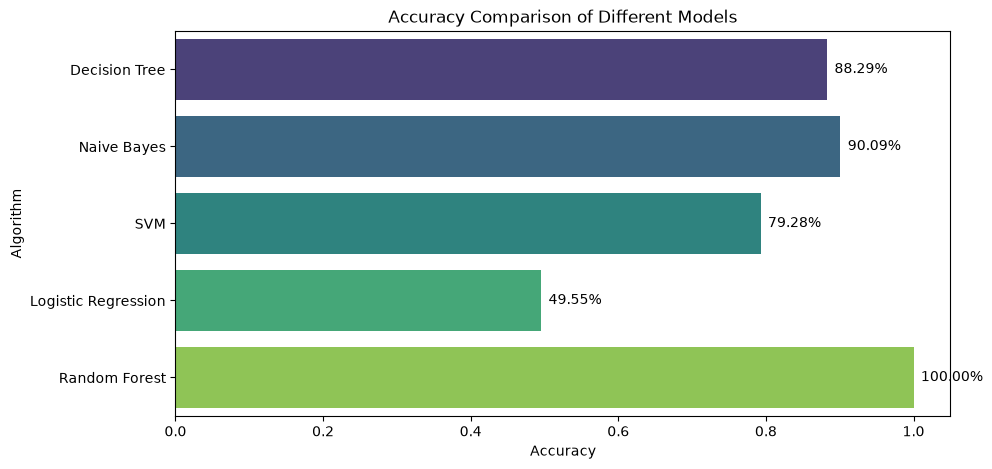

In [15]:
# Compare models' testing accuracy using a bar plot
plt.figure(figsize=[10, 5], dpi=100)
plt.title('Accuracy Comparison of Different Models')
plt.xlabel('Accuracy')
plt.ylabel('Algorithm')
sns.barplot(x='Testing Accuracy', y='Model', data=results_df, palette='viridis')
plt.xlim(0, 1.05)
for index, value in enumerate(results_df['Testing Accuracy']):
    plt.text(value + 0.01, index, f'{value * 100:.2f}%', va='center')
plt.show()

In [16]:
# Select and pickle the best performing model (e.g. Random Forest)
best_model_name = results_df.loc[results_df['Testing Accuracy'].idxmax()]['Model']
print(f"The best performing model is: {best_model_name}")

best_model = models[best_model_name]

# Save the best model
with open('classifier.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"Saved the best model ({best_model_name}) to classifier.pkl successfully!")

The best performing model is: Random Forest
Saved the best model (Random Forest) to classifier.pkl successfully!
